8. In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its `normal()` method to generate a predictor **X** of length **n = 100**, as well as a noise vector **ε** of length **n = 100**.


In [13]:
import numpy as np

rng = np.random.default_rng(1)  # seed for reproducibility
n = 100

X = rng.normal(size=n)
eps = rng.normal(size=n)


(b) Generate a response vector Y of length n = 100 according to the model

$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon
$$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [14]:
# choose constants
beta0, beta1, beta2, beta3 = 1.0, 2.0, -1.5, 0.7

Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + eps


In [6]:
import pandas as pd

def make_poly_df(X, max_deg=10):
    df = pd.DataFrame({"X1": X})
    for d in range(2, max_deg + 1):
        df[f"X{d}"] = X**d
    return df

X_poly = make_poly_df(X, 10)
X_poly.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.345584,0.119428,0.041273,0.014263,0.004929,0.001703,0.000589,0.000203,0.000070,0.000024
1,0.821618,0.675056,0.554639,0.455701,0.374412,0.307624,0.252749,0.207663,0.170620,0.140185
2,0.330437,0.109189,0.036080,0.011922,0.003940,0.001302,0.000430,0.000142,0.000047,0.000016
3,-1.303157,1.698219,-2.213046,2.883947,-3.758236,4.897573,-6.382308,8.317150,-10.838554,14.124341
4,0.905356,0.819669,0.742092,0.671858,0.608270,0.550701,0.498580,0.451393,0.408671,0.369993


In [7]:
import statsmodels.api as sm

def fit_ols(y, X_df):
    X_const = sm.add_constant(X_df)
    model = sm.OLS(y, X_const).fit()
    rss = np.sum(model.resid**2)
    return model, rss

def mallows_cp(rss, sigma2_hat, n, p):
    # p includes intercept
    return rss/sigma2_hat - (n - 2*p)


(c) Use **forward stepwise selection** in order to select a model containing the predictors:

$$
X,\; X^2,\; \ldots,\; X^{10}.
$$

What is the model obtained according to **Cₚ**? Report the **coefficients** of the model obtained.

In [8]:
def forward_stepwise_cp(y, X_df):
    n = len(y)
    cols = list(X_df.columns)

    # sigma^2 from full model
    full_model, full_rss = fit_ols(y, X_df)
    sigma2_hat = full_rss / (n - (len(cols) + 1))

    selected, remaining = [], cols.copy()
    history = []

    while remaining:
        best_cp, best_col, best_model = np.inf, None, None

        for col in remaining:
            trial = selected + [col]
            model, rss = fit_ols(y, X_df[trial])
            p = len(trial) + 1
            cp = mallows_cp(rss, sigma2_hat, n, p)

            if cp < best_cp:
                best_cp, best_col, best_model = cp, col, model

        selected.append(best_col)
        remaining.remove(best_col)
        history.append((selected.copy(), best_cp, best_model))

    best_step = min(history, key=lambda t: t[1])
    return best_step, history


best_forward, forward_hist = forward_stepwise_cp(Y, X_poly)
f_cols, f_cp, f_model = best_forward

print("Forward Cp-best predictors:", f_cols)
print("Cp:", f_cp)
print("Coefficients:\n", f_model.params)


Forward Cp-best predictors: ['X3', 'X2', 'X1', 'X10']
Cp: 2.907601472554603
Coefficients:
 const    1.053401
X3       0.811917
X2      -1.741048
X1       1.775642
X10      0.000270
dtype: float64


(d) Repeat part (c) using **backward stepwise selection**. How does your answer compare to the results in (c)?

In [9]:
def backward_stepwise_cp(y, X_df):
    n = len(y)
    cols = list(X_df.columns)

    full_model, full_rss = fit_ols(y, X_df)
    sigma2_hat = full_rss / (n - (len(cols) + 1))

    selected = cols.copy()
    history = []

    while len(selected) > 0:
        model, rss = fit_ols(y, X_df[selected])
        p = len(selected) + 1
        cp_current = mallows_cp(rss, sigma2_hat, n, p)
        history.append((selected.copy(), cp_current, model))

        if len(selected) == 1:
            break

        best_cp, best_remove, best_model = np.inf, None, None
        for col in selected:
            trial = [c for c in selected if c != col]
            trial_model, trial_rss = fit_ols(y, X_df[trial])
            p_trial = len(trial) + 1
            cp_trial = mallows_cp(trial_rss, sigma2_hat, n, p_trial)

            if cp_trial < best_cp:
                best_cp, best_remove, best_model = cp_trial, col, trial_model

        selected.remove(best_remove)

    best_step = min(history, key=lambda t: t[1])
    return best_step, history


best_backward, backward_hist = backward_stepwise_cp(Y, X_poly)
b_cols, b_cp, b_model = best_backward

print("Backward Cp-best predictors:", b_cols)
print("Cp:", b_cp)
print("Coefficients:\n", b_model.params)


Backward Cp-best predictors: ['X1', 'X2', 'X7', 'X9']
Cp: 5.616873798146969
Coefficients:
 const    1.005243
X1       2.529503
X2      -1.740343
X7       0.074552
X9      -0.009122
dtype: float64


(e)
Fit a **lasso model** to the simulated data, again using the predictors:

$$
X,\; X^2,\; \ldots,\; X^{10}.
$$

Use **cross-validation** to select the optimal value of λ.

Tasks:
1. Create a plot of the cross-validation error as a function of λ.  
2. Report the resulting coefficient estimates.  
3. Discuss the results obtained.

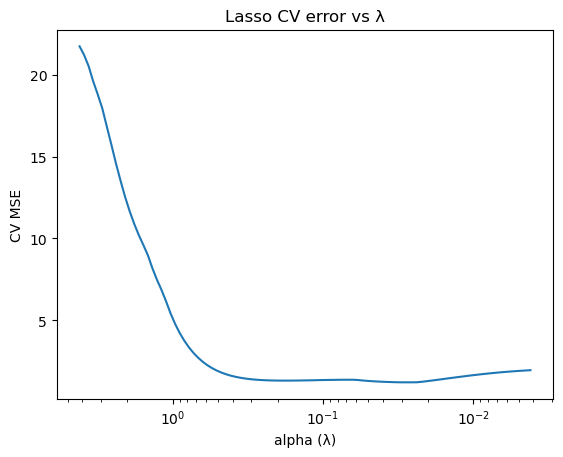

Best λ: 0.029395687231521066
Non-zero coefficients:
 X1     1.580297
X2    -1.972269
X3     2.188428
X10    0.406716
dtype: float64


In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

X = X_poly.values

lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=1, max_iter=20000)
)
lasso_pipe.fit(X, Y)

lasso = lasso_pipe.named_steps["lassocv"]
alphas = lasso.alphas_
mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("alpha (λ)")
plt.ylabel("CV MSE")
plt.title("Lasso CV error vs λ")
plt.show()

coef = pd.Series(lasso.coef_, index=X_poly.columns)
print("Best λ:", lasso.alpha_)
print("Non-zero coefficients:\n", coef[coef != 0])


(f) Now generate a response vector **Y** according to the model:

$$
Y = \beta_0 + \beta_7 X^7 + \epsilon.
$$

Then perform **forward stepwise selection** and **lasso**. Discuss the results obtained.

In [11]:
# new response
beta0_f, beta7_f = 1.0, 3.0
Y2 = beta0_f + beta7_f*(X_poly["X7"].values) + eps

# forward on new Y
best_forward_f, _ = forward_stepwise_cp(Y2, X_poly)
f2_cols, f2_cp, f2_model = best_forward_f

print("Forward Cp-best predictors (new Y):", f2_cols)
print("Coefficients:\n", f2_model.params)

# lasso on new Y
lasso_pipe.fit(X, Y2)
lasso2 = lasso_pipe.named_steps["lassocv"]
coef2 = pd.Series(lasso2.coef_, index=X_poly.columns)

print("Best λ (new Y):", lasso2.alpha_)
print("Non-zero coefficients (new Y):\n", coef2[coef2 != 0])


Forward Cp-best predictors (new Y): ['X7', 'X9', 'X4']
Coefficients:
 const    0.968628
X7       3.016236
X9      -0.002819
X4      -0.041698
dtype: float64
Best λ (new Y): 0.34171207883136123
Non-zero coefficients (new Y):
 X5     18.691777
X7    295.502639
X9     27.746342
dtype: float64
